# Rocket / Falling Stick Vertical Landing Catch Simulation

This notebook simulates a falling rocket-like stick above a moving landing cart. It includes gravity, thrust, horizontal control, angular stabilization, and spring-damper contact with the cart deck. It is a toy physics model for visualization and extension, not a full aerospace simulator.

In [1]:
import math, random, io, time, warnings
from collections import deque
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import animation
from PIL import Image, ImageDraw
from IPython.display import HTML, Image as IPyImage, display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

warnings.filterwarnings("ignore")
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def play_frames(frames, fps=30, figsize=(6, 4)):
    if not frames:
        print("(no frames)")
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return (im,)
    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000/fps, blit=True)
    html = anim.to_jshtml()
    plt.close(fig)
    display(HTML(html))


Using device: cuda
GPU: NVIDIA GeForce RTX 4090 D


,seed,status,steps,final_x,final_y,final_theta,final_vy
0,0,caught / landed,79,-0.082549,0.903206,3.205418e-07,0.420595
1,1,caught / landed,81,-0.110451,0.903400,-4.278304e-06,0.432065
2,2,caught / landed,80,-0.147795,0.904726,-3.766465e-06,0.532785
3,3,caught / landed,74,0.039505,0.893198,5.811254e-05,0.484077
4,4,caught / landed,79,-0.131663,0.904557,-2.871591e-06,0.517481
5,5,caught / landed,78,-0.125272,0.903311,1.850218e-06,0.433505
6,6,caught / landed,84,0.009539,0.915876,-4.896722e-06,0.429592
7,7,caught / landed,80,-0.111562,0.904110,-3.900306e-06,0.484336
8,8,caught / landed,77,-0.199543,0.904656,1.699646e-07,0.528117
9,9,caught / landed,79,-0.101283,0.893161,7.369016e-06,0.500228


status
caught / landed    12
Showing rollout seed=0, status=caught / landed, steps=79


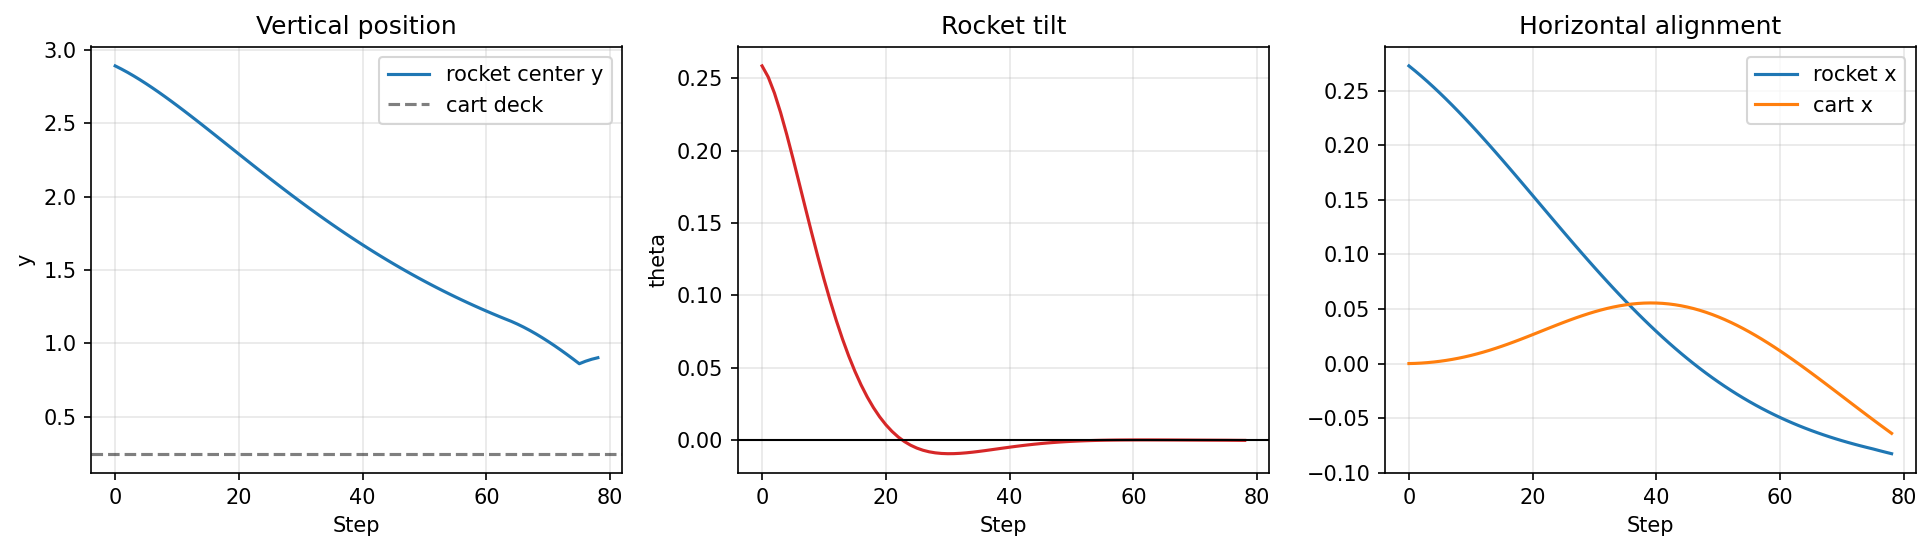

In [2]:
class FallingRocketCatchSim:
    """2D toy vertical-landing / falling-stick simulation.

    A slender rocket starts above a moving landing cart. Gravity pulls it down.
    A PD-like controller applies main thrust and side torque. When the rocket
    foot touches the cart deck, a spring-damper contact force models elasticity:

        F_contact = k * penetration - c * v_normal

    This is a visual physics model, not a real flight dynamics solver.
    """

    def __init__(self, seed=0, dt=0.025, max_steps=500):
        self.rng = np.random.default_rng(seed)
        self.dt = dt
        self.max_steps = max_steps
        self.g = 9.81
        self.mass = 1.0
        self.length = 1.25
        self.inertia = self.mass * self.length**2 / 12
        self.deck_y = 0.25
        self.k_contact = 700.0
        self.c_contact = 55.0
        self.reset(seed=seed)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.x = float(self.rng.normal(0.25, 0.18))
        self.y = float(2.9 + self.rng.normal(0, 0.08))
        self.theta = float(self.rng.normal(0.22, 0.06))
        self.vx = float(self.rng.normal(-0.18, 0.04))
        self.vy = float(-0.75 + self.rng.normal(0, 0.05))
        self.omega = float(self.rng.normal(-0.15, 0.04))
        self.cart_x = 0.0
        self.cart_v = 0.0
        self.steps = 0
        self.done = False
        self.status = "falling"
        return self.state()

    def state(self):
        return np.array([self.x, self.y, self.theta, self.vx, self.vy, self.omega, self.cart_x, self.cart_v], dtype=np.float32)

    def controller(self):
        # Move cart under the projected rocket foot.
        foot_x = self.x - 0.5 * self.length * math.sin(self.theta)
        cart_acc = 4.0 * (foot_x - self.cart_x) + 1.2 * (self.vx - self.cart_v)
        cart_acc = float(np.clip(cart_acc, -3.0, 3.0))

        # Rocket thrust: descend toward the deck and then unload thrust so the
        # spring-damper landing gear can settle instead of hovering forever.
        foot_y_est = self.y - 0.5 * self.length * math.cos(self.theta)
        if foot_y_est > self.deck_y + 0.28:
            target_vy = -0.34
            desired_y = self.deck_y + 0.5 * self.length + 0.10
            thrust = self.mass * self.g + 3.0 * (target_vy - self.vy) + 2.2 * (desired_y - self.y)
        else:
            target_vy = -0.04
            desired_y = self.deck_y + 0.5 * self.length
            thrust = 0.62 * self.mass * self.g + 2.0 * (target_vy - self.vy) + 2.5 * (desired_y - self.y)
        thrust = float(np.clip(thrust, 0.0, 16.0))

        # Side thrust and torque stabilize x and angle.
        side_force = -1.7 * (self.x - self.cart_x) - 0.75 * self.vx
        side_force = float(np.clip(side_force, -3.5, 3.5))
        torque = -4.0 * self.theta - 1.0 * self.omega
        torque = float(np.clip(torque, -2.4, 2.4))
        return cart_acc, thrust, side_force, torque

    def step(self):
        if self.done:
            return self.state(), self.done, self.status
        dt = self.dt
        cart_acc, thrust, side_force, torque = self.controller()

        self.cart_v += cart_acc * dt
        self.cart_x += self.cart_v * dt
        self.cart_v *= 0.995

        fx = side_force
        fy = thrust - self.mass * self.g
        tau = torque

        foot = np.array([
            self.x - 0.5 * self.length * math.sin(self.theta),
            self.y - 0.5 * self.length * math.cos(self.theta),
        ])
        foot_v = np.array([
            self.vx - 0.5 * self.length * math.cos(self.theta) * self.omega,
            self.vy + 0.5 * self.length * math.sin(self.theta) * self.omega,
        ])
        cart_half_width = 0.75
        on_deck_x = abs(foot[0] - self.cart_x) <= cart_half_width
        penetration = self.deck_y - foot[1]
        contact_force = 0.0
        if penetration > 0 and on_deck_x:
            contact_force = self.k_contact * penetration - self.c_contact * foot_v[1]
            contact_force = max(0.0, min(contact_force, 250.0))
            fy += contact_force
            lever_x = foot[0] - self.x
            tau += lever_x * contact_force
            # Coulomb-like horizontal damping during contact.
            fx += -2.5 * (foot_v[0] - self.cart_v)

        ax = fx / self.mass
        ay = fy / self.mass
        alpha = tau / self.inertia
        self.vx += ax * dt
        self.vy += ay * dt
        self.omega += alpha * dt
        self.x += self.vx * dt
        self.y += self.vy * dt
        self.theta += self.omega * dt
        self.steps += 1

        foot_after = np.array([
            self.x - 0.5 * self.length * math.sin(self.theta),
            self.y - 0.5 * self.length * math.cos(self.theta),
        ])
        stable_contact = (
            abs(foot_after[1] - self.deck_y) < 0.08
            and abs(foot_after[0] - self.cart_x) < 0.65
            and abs(self.theta) < 0.24
            and abs(self.vy) < 0.42
            and abs(self.omega) < 0.55
        )
        if stable_contact and self.steps > 45:
            self.done = True
            self.status = "caught / landed"
        elif self.y < -0.3 or abs(self.theta) > 1.25 or self.steps >= self.max_steps:
            self.done = True
            self.status = "failed" if self.steps < self.max_steps else "timeout"
        else:
            self.status = "contact" if contact_force > 0 else "falling"
        return self.state(), self.done, self.status

    def render_frame(self):
        width, height = 700, 460
        img = Image.new("RGB", (width, height), "white")
        draw = ImageDraw.Draw(img)

        def px(x, y):
            return int((x + 3.0) / 6.0 * width), int(height - ((y + 0.2) / 3.8 * height))

        for gx in np.linspace(-2.5, 2.5, 6):
            draw.line((*px(gx, -0.1), *px(gx, 3.4)), fill=(238, 238, 238), width=1)
        for gy in np.linspace(0.0, 3.2, 5):
            draw.line((*px(-2.8, gy), *px(2.8, gy)), fill=(238, 238, 238), width=1)

        deck_l = px(self.cart_x - 0.75, self.deck_y)
        deck_r = px(self.cart_x + 0.75, self.deck_y)
        cart_bottom = px(self.cart_x + 0.75, self.deck_y - 0.18)
        draw.rectangle((deck_l[0], deck_l[1], deck_r[0], cart_bottom[1]), fill=(35, 35, 35))
        draw.ellipse((deck_l[0]+20, cart_bottom[1]-8, deck_l[0]+46, cart_bottom[1]+18), fill=(80, 80, 80))
        draw.ellipse((deck_r[0]-46, cart_bottom[1]-8, deck_r[0]-20, cart_bottom[1]+18), fill=(80, 80, 80))

        center = np.array([self.x, self.y])
        top = center + np.array([0.5 * self.length * math.sin(self.theta), 0.5 * self.length * math.cos(self.theta)])
        foot = center - np.array([0.5 * self.length * math.sin(self.theta), 0.5 * self.length * math.cos(self.theta)])
        t = px(*top); f = px(*foot)
        draw.line((*f, *t), fill=(214, 39, 40), width=12)
        draw.ellipse((f[0]-6, f[1]-6, f[0]+6, f[1]+6), fill=(214, 39, 40))

        # Flame vector from bottom when thrusting.
        flame_len = int(8 + 15 * max(0, self.mass*self.g - self.vy) / 20)
        draw.polygon([(f[0]-7, f[1]+2), (f[0]+7, f[1]+2), (f[0], f[1]+flame_len)], fill=(255, 140, 0))

        draw.text((14, 14), f"Falling rocket/stick catch simulation | step {self.steps}", fill=(20, 20, 20))
        draw.text((14, 38), f"status={self.status}, theta={self.theta:+.2f}, y={self.y:.2f}, vy={self.vy:+.2f}", fill=(70, 70, 70))
        draw.text((14, 62), "Physics: gravity + thrust + spring-damper contact with moving cart deck", fill=(70, 70, 70))
        return np.asarray(img)


def run_one(seed=0, max_steps=500, keep_frames=True):
    sim = FallingRocketCatchSim(seed=seed, max_steps=max_steps)
    frames = []
    trajectory = []
    done = False
    while not done and len(trajectory) < max_steps:
        if keep_frames:
            frames.append(sim.render_frame())
        trajectory.append(sim.state().copy())
        _, done, status = sim.step()
    return status, len(trajectory), np.array(trajectory), frames


rollouts = []
for seed in range(12):
    status, steps, traj, frames = run_one(seed=seed, keep_frames=True)
    rollouts.append((seed, status, steps, traj, frames))

summary = pd.DataFrame([
    {"seed": seed, "status": status, "steps": steps,
     "final_x": traj[-1, 0], "final_y": traj[-1, 1], "final_theta": traj[-1, 2],
     "final_vy": traj[-1, 4]}
    for seed, status, steps, traj, frames in rollouts
])
display(summary)
print(summary["status"].value_counts().to_string())

successes = [item for item in rollouts if item[1] == "caught / landed"]
chosen = successes[0] if successes else max(rollouts, key=lambda item: item[2])
seed, status, steps, traj, frames = chosen
print(f"Showing rollout seed={seed}, status={status}, steps={steps}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(traj[:, 1], label="rocket center y")
axes[0].axhline(0.25, color="black", ls="--", alpha=0.5, label="cart deck")
axes[0].set_title("Vertical position")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("y")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(traj[:, 2], color="tab:red")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Rocket tilt")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("theta")
axes[1].grid(alpha=0.3)
axes[2].plot(traj[:, 0], label="rocket x")
axes[2].plot(traj[:, 6], label="cart x")
axes[2].set_title("Horizontal alignment")
axes[2].set_xlabel("Step"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(IPyImage(data=buf.getvalue()))
play_frames(frames, fps=30, figsize=(7, 4.6))
